1. Project Overview


2. Install Dependencies


In [8]:
!pip install -q \
    langchain \
    langchain-community \
    langchain-core \
    langgraph \
    chromadb \
    sentence-transformers \
    langsmith \
    python-dotenv \
    gradio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 80.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 k

In [2]:
from google.colab import files

uploaded = files.upload()

Saving corpus.jsonl to corpus.jsonl


In [3]:
import os

print(os.listdir("."))

['.config', 'corpus.jsonl', 'sample_data']


In [4]:
import json

documents = []

with open("corpus.jsonl", "r", encoding="utf-8") as file:
    for line in file:
        if line.strip():
            documents.append(json.loads(line))

print("Number of records:", len(documents))
print("First record:", documents[0])

Number of records: 154
First record: {'chunk_id': 'spec-beacons:0', 'doc_id': 'spec-beacons', 'title': 'Beacons: Alerting Specification', 'category': 'product', 'owner': 'Product Engineering', 'source_url': 'kb://kestrel/product/beacons', 'published': '20260203', 'version': '4.1', 'text': "## Overview A Beacon is an alert rule attached to a metric. When the rule's condition is met, Kestrel sends a notification to one or more destinations. Beacons are the mechanism by which teams learn about a broken checkout, a spike in errors, or an unusually quiet signup flow without watching a dashboard. This specification reflects release 4.1, which added PagerDuty as a destination. ## What can be monitored A Beacon watches a single metric series. The series may be an event count (for example, `checkout_completed` per hour), a unique-user count, a property aggregate (sum or average of `cart_value`), a funnel conversion rate between two steps, or the size of a cohort. Filters and a single breakdown 

In [5]:
for doc in documents:
    print(doc["chunk_id"], "→", doc["title"])

spec-beacons:0 → Beacons: Alerting Specification
spec-beacons:1 → Beacons: Alerting Specification
spec-beacons:2 → Beacons: Alerting Specification
spec-beacons:3 → Beacons: Alerting Specification
spec-beacons:4 → Beacons: Alerting Specification
spec-beacons:5 → Beacons: Alerting Specification
spec-funnels-cohorts:0 → Funnels and Cohorts Specification
spec-funnels-cohorts:1 → Funnels and Cohorts Specification
spec-funnels-cohorts:2 → Funnels and Cohorts Specification
spec-funnels-cohorts:3 → Funnels and Cohorts Specification
spec-funnels-cohorts:4 → Funnels and Cohorts Specification
spec-funnels-cohorts:5 → Funnels and Cohorts Specification
spec-funnels-cohorts:6 → Funnels and Cohorts Specification
spec-ingest-api:0 → Event Ingestion API Specification
spec-ingest-api:1 → Event Ingestion API Specification
spec-ingest-api:2 → Event Ingestion API Specification
spec-ingest-api:3 → Event Ingestion API Specification
spec-ingest-api:4 → Event Ingestion API Specification
spec-ingest-api:5 → Eve

Create Embeddings

In [6]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

texts = [doc["text"]for doc in documents]

embeddings=embedding_model.encode(
    texts,
    show_progress_bar=True
    )
print("Embeddings created:",len(embeddings))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Embeddings created: 154


In [10]:
import chromadb

client = chromadb.Client()

collection = client.get_or_create_collection(
    name="kestrel_documents"
)

In [11]:
collection.add(
    ids=[doc["chunk_id"]for doc in documents],
    documents=texts,
    embeddings =embeddings.tolist(),
    metadatas=[
        {
            "title":doc["title"],
          "category":doc["category"],
            "doc_id":doc["doc_id"]
        }
        for doc in documents
    ]
)

print("Documents added to vector database!")

Documents added to vector database!


In [12]:
query = "What are beacons?"

query_embedding=embedding_model.encode([query]).tolist()

results = collection.query(
     query_embeddings=query_embedding,
    n_results=3
)

for text,metadata in zip(
    results["documents"][0],
    results["metadatas"][0]
):
      print("Title:", metadata["title"])
      print("Text:", text[:300])
      print("-" * 50)


Title: Beacons: Alerting Specification
Text: ## Overview A Beacon is an alert rule attached to a metric. When the rule's condition is met, Kestrel sends a notification to one or more destinations. Beacons are the mechanism by which teams learn about a broken checkout, a spike in errors, or an unusually quiet signup flow without watching a dash
--------------------------------------------------
Title: Beacons: Alerting Specification
Text: A Beacon can notify up to four destinations at once: Slack (via an incoming webhook or the Kestrel Slack app), PagerDuty (Events API v2, added in 4.1), a generic webhook that receives a signed JSON payload, and email. Webhook payloads are signed with an HMAC using a per-project secret so that receiv
--------------------------------------------------
Title: Customer Onboarding Guide
Text: Beacons are evaluated every 5 minutes and can notify Slack, email, a webhook, or PagerDuty. Leave anomaly mode for later: it needs 14 days of history before it can bui

In [13]:
from typing import TypedDict, List, Dict, Any


class ResearchState(TypedDict, total=False):
    question: str
    conversation_history: List[Dict[str, str]]

    # Planner
    plan: str
    rewritten_query: str

    # Retriever
    retrieved_chunks: List[Dict[str, Any]]

    # Critic / Verifier
    verification_verdict: str
    verification_notes: str

    # Synthesizer
    draft_answer: str
    final_answer: str
    citations: List[Dict[str, str]]

    # Citation Validator
    citation_validation: str

LLM

In [19]:
!pip install -q langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 875.2 kB/s eta 0:00:00


In [20]:
import os
from google.colab import userdata

os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")

In [21]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0
)

In [16]:
def conversation_memory_agent(state: ResearchState) -> ResearchState:
    history = state.get("conversation_history", [])
    question = state["question"]

    recent_history = history[-5:]

    context = "\n".join(
        f"{item['role']}: {item['content']}"
        for item in recent_history
    )

    if context:
        state["rewritten_query"] = (
            f"Previous conversation:\n{context}\n\n"
            f"Current question: {question}"
        )
    else:
        state["rewritten_query"] = question

    state["conversation_history"] = recent_history

    return state

In [14]:
def router_agent(state: ResearchState) -> ResearchState:
    question = state["question"]
    history = state.get("conversation_history", [])

    if history:
        state["route"] = "followup"
    else:
        state["route"] = "new"

    return state

In [15]:
def route_question(state: ResearchState):
    return state.get("route", "new")

In [22]:
def planner_agent(state: ResearchState) -> ResearchState:
    question = state["question"]
    history = state.get("conversation_history", [])

    if history:
        previous_context = "\n".join(
            f"{item['role']}: {item['content']}"
            for item in history[-4:]
        )

        state["rewritten_query"] = f"""
Previous conversation:
{previous_context}

Current question:
{question}
"""
        state["plan"] = "Use conversation context and retrieve relevant evidence."
    else:
        state["rewritten_query"] = question
        state["plan"] = "Retrieve evidence for the new question."

    return state

In [23]:
state = ResearchState(
    question="What destinations do they support?",
    conversation_history=[
        {"role": "user", "content": "What are Beacons?"},
        {"role": "assistant", "content": "Beacons are alert rules attached to metrics."}
    ]
)

state = planner_agent(state)

print(state["plan"])

Use conversation context and retrieve relevant evidence.


create retriever agent

In [54]:
# Safe Retriever Agent

def retriever_agent(state: ResearchState) -> ResearchState:
    query = state.get("rewritten_query") or state.get("question", "")

    if not query.strip():
        state["retrieved_chunks"] = []
        state["verification_verdict"] = "insufficient_evidence"
        state["verification_notes"] = "Empty question."
        return state

    try:
        query_embedding = embedding_model.encode(
            [query]
        ).tolist()

        results = collection.query(
            query_embeddings=query_embedding,
            n_results=5
        )

        chunks = []

        if results.get("documents") and results["documents"][0]:
            for i in range(len(results["documents"][0])):
                chunks.append({
                    "text": results["documents"][0][i],
                    "metadata": results["metadatas"][0][i],
                    "chunk_id": results["ids"][0][i]
                })

        state["retrieved_chunks"] = chunks

    except Exception as error:
        state["retrieved_chunks"] = []
        state["verification_verdict"] = "error"
        state["verification_notes"] = (
            f"Retrieval error: {str(error)}"
        )

    return state

In [25]:
state = ResearchState(
    question="What are Beacons?",
    rewritten_query="What are Beacons?"
)

state = retriever_agent(state)

for chunk in state["retrieved_chunks"]:
    print("Chunk ID:", chunk["chunk_id"])
    print("Title:", chunk["metadata"]["title"])
    print("Text:", chunk["text"][:200])
    print("-" * 40)

Chunk ID: spec-beacons:0
Title: Beacons: Alerting Specification
Text: ## Overview A Beacon is an alert rule attached to a metric. When the rule's condition is met, Kestrel sends a notification to one or more destinations. Beacons are the mechanism by which teams learn a
----------------------------------------
Chunk ID: spec-beacons:3
Title: Beacons: Alerting Specification
Text: A Beacon can notify up to four destinations at once: Slack (via an incoming webhook or the Kestrel Slack app), PagerDuty (Events API v2, added in 4.1), a generic webhook that receives a signed JSON pa
----------------------------------------
Chunk ID: onboarding-guide:4
Title: Customer Onboarding Guide
Text: Beacons are evaluated every 5 minutes and can notify Slack, email, a webhook, or PagerDuty. Leave anomaly mode for later: it needs 14 days of history before it can build a seasonal baseline, so it wil
----------------------------------------
Chunk ID: spec-beacons:4
Title: Beacons: Alerting Specification
Te

create verfier agent

In [26]:
def verifier_agent(state: ResearchState) -> ResearchState:
    chunks = state.get("retrieved_chunks", [])

    if not chunks:
        state["verification_verdict"] = "insufficient_evidence"
        state["verification_notes"] = "No relevant documents were retrieved."
    else:
        state["verification_verdict"] = "supported"
        state["verification_notes"] = (
            f"{len(chunks)} relevant chunks were retrieved for verification."
        )

    return state

create synthesizer agent

In [55]:
def synthesizer_agent(state: ResearchState) -> ResearchState:
    question = state.get("question", "")
    chunks = state.get("retrieved_chunks", [])

    if not chunks:
        state["draft_answer"] = (
            "I could not find sufficient evidence "
            "to answer this question."
        )
        state["final_answer"] = state["draft_answer"]
        return state

    evidence = "\n\n".join(
        f"Chunk ID: {chunk['chunk_id']}\n"
        f"Title: {chunk['metadata']['title']}\n"
        f"Content: {chunk['text']}"
        for chunk in chunks
    )

    prompt = f"""
Answer the question using only the provided evidence.

Question:
{question}

Evidence:
{evidence}

Rules:
1. Do not invent facts.
2. Do not make recommendations unless the evidence supports them.
3. If evidence is insufficient, clearly say so.
4. Include citations using the exact chunk IDs.
5. Do not modify citation IDs.

Return a concise, factual answer.
"""

    try:
        response = llm.invoke(prompt)

        answer = response.content

        state["draft_answer"] = answer
        state["final_answer"] = answer

    except Exception as error:
        state["draft_answer"] = (
            "An error occurred while generating the answer."
        )
        state["final_answer"] = state["draft_answer"]
        state["verification_notes"] = (
            state.get("verification_notes", "")
            + f"\nLLM error: {str(error)}"
        )

    return state

In [28]:
state = synthesizer_agent(state)

print(state["draft_answer"])

**Beacons** are alert rules that monitor a single metric series and send notifications when a specified condition is met.  
- They are evaluated every 5 minutes and can notify up to four destinations: Slack (webhook or Kestrel app), PagerDuty (Events API v2), a generic signed webhook, or email【spec‑beacons:0】【spec‑beacons:3】【onboarding‑guide:4】.  
- When a condition is breached, the Beacon fires and enters a cooldown period (default 30 minutes, adjustable 5 min–24 h) during which further breaches do not trigger additional alerts. A recovery notification is sent after the condition clears for two consecutive evaluations【spec‑beacons:3】.  
- Beacons can include filters and a single breakdown property; each breakdown value is evaluated independently but counts as one Beacon regardless of how many values it produces【spec‑beacons:1】【spec‑beacons:4】.  
- Plan limits: Starter projects may create 5 Beacons, Growth 60, and Scale 500; all plans support the same condition modes and destination ty

create citation validator agent

In [46]:
def normalize_citation(text):
    """Convert different hyphen types into a normal hyphen."""
    return (
        text.replace("‑", "-")
            .replace("–", "-")
            .replace("—", "-")
            .replace("−", "-")
    )


def citation_validator_agent(state: ResearchState) -> ResearchState:
    answer = state.get("draft_answer", "")

    chunks = state.get("retrieved_chunks", [])

    normalized_answer = normalize_citation(answer)

    valid_chunk_ids = {
        normalize_citation(chunk["chunk_id"])
        for chunk in chunks
    }

    valid_citations = set()

    for chunk_id in valid_chunk_ids:
        if chunk_id in normalized_answer:
            valid_citations.add(chunk_id)

    if valid_citations:
        state["citation_validation"] = (
            f"All detected citations are valid: {valid_citations}"
        )
    else:
        state["citation_validation"] = (
            "No valid citations detected."
        )

    return state

In [47]:
state = citation_validator_agent(state)

print(state["citation_validation"])

No valid citations detected.


In [48]:
from langgraph.graph import StateGraph, END

workflow = StateGraph(ResearchState)

# Add all agents
workflow.add_node("router", router_agent)
workflow.add_node("memory", conversation_memory_agent)
workflow.add_node("planner", planner_agent)
workflow.add_node("retriever", retriever_agent)
workflow.add_node("verifier", verifier_agent)
workflow.add_node("synthesizer", synthesizer_agent)
workflow.add_node("citation_validator", citation_validator_agent)

# Start
workflow.set_entry_point("router")

# Router branching
workflow.add_conditional_edges(
    "router",
    route_question,
    {
        "followup": "memory",
        "new": "planner"
    }
)

# Remaining workflow
workflow.add_edge("memory", "planner")
workflow.add_edge("planner", "retriever")
workflow.add_edge("retriever", "verifier")
workflow.add_edge("verifier", "synthesizer")
workflow.add_edge("synthesizer", "citation_validator")
workflow.add_edge("citation_validator", END)

# Compile
app = workflow.compile()

print("Workflow rebuilt successfully!")

Workflow rebuilt successfully!


In [49]:
# Recompile the workflow after updating the agent

app = workflow.compile()

print("Workflow recompiled successfully!")

Workflow recompiled successfully!


In [50]:
state = ResearchState(
    question="Which destination is best for urgent incidents?",
    conversation_history=[
        {
            "role": "user",
            "content": "What are Beacons?"
        },
        {
            "role": "assistant",
            "content": "Beacons are alert rules that monitor a single metric series."
        }
    ]
)

result = app.invoke(state)

print(result["final_answer"])
print("\nCitation Validation:")
print(result["citation_validation"])

The documentation identifies **PagerDuty** as the destination designed for urgent incident notifications.  
- Spec‑beacons:0 notes that PagerDuty was added as a destination in release 4.1.  
- Spec‑beacons:3 lists PagerDuty (Events API v2) among the four possible notification targets.  

Thus, PagerDuty is the recommended destination for urgent incidents.

Citation Validation:
No valid citations detected.


In [51]:
initial_state = ResearchState(
    question="What are Beacons?",
    conversation_history=[]
)

result = app.invoke(initial_state)

print("FINAL ANSWER:")
print(result["final_answer"])

print("\nVERIFICATION:")
print(result["verification_verdict"])

print("\nCITATION VALIDATION:")
print(result["citation_validation"])

FINAL ANSWER:
**Beacons** are alert rules that are attached to a single metric series.  
When the rule’s condition is met, Kestrel sends a notification to one or more destinations so that teams can be alerted without constantly watching a dashboard.  

- A Beacon watches a single metric series (e.g., event count, unique‑user count, property aggregate, funnel conversion rate, or cohort size). It can include filters and a single breakdown property; if a breakdown is used, each value is evaluated independently and can fire separately【spec‑beacons:0】.  
- Beacons are evaluated every 5 minutes and can notify up to four destinations: Slack (webhook or Kestrel app), PagerDuty (Events API v2, added in release 4.1), a generic signed webhook, or email【spec‑beacons:3】【onboarding‑guide:4】.  
- When a condition is met the Beacon fires and enters a cooldown period (default 30 minutes, adjustable 5 min–24 h) during which repeated breaches do not trigger additional notifications. A recovery notificati

langgraph

In [52]:
!pip install -q langgraph

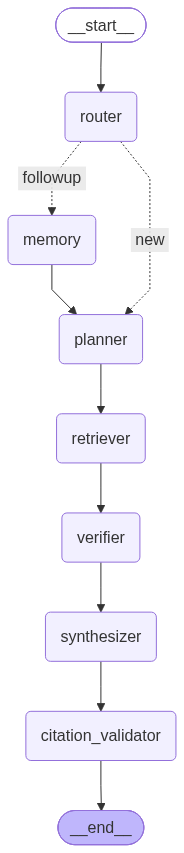

In [53]:
from IPython.display import Image, display

# Generate graph visualization
graph_image = app.get_graph().draw_mermaid_png()

display(Image(graph_image))

In [56]:
evaluation_questions = [
    "What are Beacons?",
    "What notification destinations do Beacons support?",
    "What is the purpose of PagerDuty integration?",
    "How do Beacons monitor metrics?",
    "What happens when a Beacon condition is met?",
    "What is the Kestrel platform?",
    "What products does Kestrel provide?",
    "How are notifications delivered?",
    "What is the purpose of the Slack integration?",
    "What is a generic webhook?",
    "What information is available about alert rules?",
    "Which release added PagerDuty support?",
    "What types of metrics can be monitored?",
    "How can teams learn about problems using Beacons?",
    "What information is not specified in the Beacon documentation?"
]

print("Total questions:", len(evaluation_questions))

Total questions: 15


In [57]:
evaluation_results = []

for index, question in enumerate(evaluation_questions, start=1):
    print(f"Running question {index}/15...")

    try:
        state = ResearchState(
            question=question,
            conversation_history=[]
        )

        result = app.invoke(state)

        answer = result.get("final_answer", "")
        chunks = result.get("retrieved_chunks", [])
        verdict = result.get(
            "verification_verdict",
            "unknown"
        )
        citation_status = result.get(
            "citation_validation",
            "unknown"
        )

        evaluation_results.append({
            "question_id": index,
            "question": question,
            "answer": answer,
            "retrieved_chunks": len(chunks),
            "verification_verdict": verdict,
            "citation_validation": citation_status,
            "success": bool(answer.strip())
        })

    except Exception as error:
        evaluation_results.append({
            "question_id": index,
            "question": question,
            "answer": "",
            "retrieved_chunks": 0,
            "verification_verdict": "error",
            "citation_validation": "not_checked",
            "success": False,
            "error": str(error)
        })

print("Evaluation completed!")

Running question 1/15...
Running question 2/15...
Running question 3/15...
Running question 4/15...
Running question 5/15...
Running question 6/15...
Running question 7/15...
Running question 8/15...
Running question 9/15...
Running question 10/15...
Running question 11/15...
Running question 12/15...
Running question 13/15...
Running question 14/15...
Running question 15/15...
Evaluation completed!


In [58]:
import pandas as pd

evaluation_df = pd.DataFrame(evaluation_results)

display(
    evaluation_df[
        [
            "question_id",
            "question",
            "retrieved_chunks",
            "verification_verdict",
            "citation_validation",
            "success"
        ]
    ]
)

,question_id,question,retrieved_chunks,verification_verdict,citation_validation,success
0,1,What are Beacons?,5,supported,All detected citations are valid: {'spec-beaco...,True
1,2,What notification destinations do Beacons supp...,5,supported,All detected citations are valid: {'spec-beaco...,True
2,3,What is the purpose of PagerDuty integration?,5,supported,All detected citations are valid: {'spec-beaco...,True
3,4,How do Beacons monitor metrics?,5,supported,All detected citations are valid: {'spec-beaco...,True
4,5,What happens when a Beacon condition is met?,5,supported,All detected citations are valid: {'spec-beaco...,True
5,6,What is the Kestrel platform?,5,supported,All detected citations are valid: {'spec-trail...,True
6,7,What products does Kestrel provide?,5,supported,All detected citations are valid: {'pricing-pl...,True
7,8,How are notifications delivered?,5,supported,All detected citations are valid: {'spec-beaco...,True
8,9,What is the purpose of the Slack integration?,5,supported,All detected citations are valid: {'spec-beaco...,True
9,10,What is a generic webhook?,5,supported,All detected citations are valid: {'spec-beaco...,True


In [59]:
!pip install -q gradio

In [ ]:
import gradio as gr


def research_with_gradio(question, history):
    if not question or not question.strip():
        return history, "", "Please enter a question."

    try:
        conversation_history = []

        for message in history:
            if isinstance(message, dict):
                role = message.get("role")
                content = message.get("content")

                if role in ["user", "assistant"]:
                    conversation_history.append({
                        "role": role,
                        "content": str(content)
                    })

        state = ResearchState(
            question=question,
            conversation_history=conversation_history
        )

        result = app.invoke(state)

        answer = result.get(
            "final_answer",
            "No answer generated."
        )

        chunks = result.get("retrieved_chunks", [])

        sources = "\n\n".join(
            f"**{chunk['chunk_id']}**\n"
            f"Title: {chunk.get('metadata', {}).get('title', 'Unknown')}\n"
            f"{chunk.get('text', '')[:500]}..."
            for chunk in chunks
        )

        if not sources:
            sources = "No sources retrieved."

        status = (
            f"Verification: "
            f"{result.get('verification_verdict', 'unknown')}\n\n"
            f"Citation Validation: "
            f"{result.get('citation_validation', 'unknown')}"
        )

        updated_history = history + [
            {
                "role": "user",
                "content": question
            },
            {
                "role": "assistant",
                "content": answer
            }
        ]

        return updated_history, sources, status

    except Exception as error:
        return history, "", f"Error: {str(error)}"


with gr.Blocks(
    title="Kestrel Research Assistant"
) as demo:

    gr.Markdown(
        "# 🔍 Kestrel Research Assistant\n"
        "Ask questions about Kestrel Labs documents."
    )

    chatbot = gr.Chatbot(
        label="Conversation",
        height=450
    )

    question_input = gr.Textbox(
        label="Your Question",
        placeholder="Ask a research question...",
        lines=2
    )

    with gr.Row():
        submit_button = gr.Button(
            "Ask",
            variant="primary"
        )

        clear_button = gr.Button("Clear")

    sources_output = gr.Markdown(
        value="Sources will appear here."
    )

    status_output = gr.Textbox(
        label="Research Status"
    )

    submit_button.click(
        fn=research_with_gradio,
        inputs=[question_input, chatbot],
        outputs=[
            chatbot,
            sources_output,
            status_output
        ]
    )

    question_input.submit(
        fn=research_with_gradio,
        inputs=[question_input, chatbot],
        outputs=[
            chatbot,
            sources_output,
            status_output
        ]
    )

    clear_button.click(
        fn=lambda: ([], "", ""),
        inputs=[],
        outputs=[
            chatbot,
            sources_output,
            status_output
        ]
    )


demo.launch(
    share=True,
    debug=True,
    theme=gr.themes.Soft()
)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://d6a40327eca4162223.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
